# Schema-Aligned Pooled DIAD–Tabular IDS Benchmark

This notebook is part of the implementation repository for the paper:

**Beyond Accuracy: A Deployment-Aware Multi-Dataset Evaluation of Machine Learning and Deep Learning Models for IoT/IIoT Intrusion Detection.**

## Dataset Used

This notebook uses a schema-aligned merged dataset created from:

1. CIC-IoT-IDAD 2024
2. CIC-BCCC-NRC TabularIoTAttack-2024

The merge retains only the shared numeric feature schema between the two datasets. Dataset-specific columns that are not common to both sources are removed before concatenation to reduce the risk of source-identification shortcuts.

The target classes are:

1. BENIGN
2. DDOS
3. DOS
4. MIRAI
5. MQTT DOS

The experiment evaluates the merged dataset under two feature settings:

1. Full-feature setting
2. Reduced-feature setting

The full-feature setting uses the shared numeric feature space after schema alignment. The reduced-feature setting uses selected features from the training data to evaluate whether a compact representation remains effective on a harder cross-source dataset.

## Models Evaluated

The following models are evaluated:

1. Decision Tree
2. Random Forest
3. XGBoost
4. LightGBM
5. MLP/DNN
6. CNN-LSTM-Attention

## Evaluation Metrics

The evaluation includes accuracy, balanced accuracy, macro-F1, weighted-F1, false positives per 10,000 benign samples, training time, inference time, latency, throughput, and model size.

## Dataset Note

The raw datasets are not included in this repository because of size and dataset usage restrictions. Before running this notebook, download the corresponding source datasets or prepared merged dataset and update the dataset path in the configuration cell.

## Cell 1 — Configuration

In [1]:
# =========================
# CONFIGURATION
# =========================

from pathlib import Path

# Main merged dataset path.
# This is set to your local Visual Studio / VS Code output path.
# If you run this notebook somewhere else, change this path or set it to None and use the search patterns below.
DATASET_PATH = r"/kaggle/input/datasets/frazyousaf022/merged-cic-idad-2024-tabular-iot-attack-2024/merged_CIC_IDAD_2024_TABULAR_IOT_ATTACK_2024.csv"

# Optional fallback paths. The notebook will try these if DATASET_PATH is None or not found.
FALLBACK_DATASET_PATHS = [
    r"data\processed\merged_CIC_IDAD_2024_TABULAR_IOT_ATTACK_2024.csv",
    r"./data/processed/merged_CIC_IDAD_2024_TABULAR_IOT_ATTACK_2024.csv",
    r"/kaggle/input/merged-cic-idad-tabular/merged_CIC_IDAD_2024_TABULAR_IOT_ATTACK_2024.csv",
]

# Automatic CSV search patterns. The notebook prefers files containing "merged" first, then larger CSV files.
DATASET_GLOB_PATTERNS = [
    "/kaggle/input/**/*.csv",
    "./**/*.csv",
]

DATASET_NAME = "Merged CIC-IDAD-2024 + TABULAR-IOT-ATTACK-2024"

# Leave as None to auto-detect. Your merged dataset uses "Label".
LABEL_COL = None
LABEL_CANDIDATES = ["Label", "label", "Attack", "attack", "Class", "class", "Target", "target"]

# Optional: remove a class before training.
# Example: DROP_LABELS = ["MQTT DOS"]
DROP_LABELS = []

# Optional: merge label names.
# Keep empty for multiclass detection with BENIGN, DDOS, DOS, MIRAI, MQTT DOS.
# For binary classification, uncomment the mapping below and map all attack labels to ATTACK.
LABEL_REPLACEMENTS = {}

# Example binary setup:
# LABEL_REPLACEMENTS = {
#     "DDOS": "ATTACK",
#     "DOS": "ATTACK",
#     "MIRAI": "ATTACK",
#     "MQTT DOS": "ATTACK",
# }

RANDOM_SEED = 42
TEST_SIZE = 0.20

# Feature-reduction settings
TOP_K_FEATURES = 35
CORR_THRESHOLD = 0.98
FEATURE_SELECTION_SAMPLE_ROWS = 200_000
CORRELATION_SAMPLE_ROWS = 100_000

# Deep-learning settings
DL_EPOCHS = 7
DL_BATCH_SIZE = 1024
DL_PATIENCE = 2

# Inference benchmark settings
BENCHMARK_SAMPLE_SIZE = 20_000
BENCHMARK_BATCH_SIZE = 4096

# For fast testing, set this to a number such as 100_000.
# For final paper results, keep None.
MAX_ROWS = None

# Output folders
WORK_DIR = Path("/kaggle/working/merged_idad_tabular_benchmark") if Path("/kaggle/working").exists() else Path("./merged_idad_tabular_benchmark")
RESULTS_DIR = WORK_DIR / "results"
ARTIFACTS_DIR = WORK_DIR / "artifacts"
MODELS_DIR = WORK_DIR / "models"
PAPER_DIR = WORK_DIR / "paper_outputs"

for d in [WORK_DIR, RESULTS_DIR, ARTIFACTS_DIR, MODELS_DIR, PAPER_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Work directory:", WORK_DIR.resolve())


Work directory: /kaggle/working/merged_idad_tabular_benchmark


## Cell 2 — Imports and hardware check

In [2]:
# =========================
# IMPORTS AND ENVIRONMENT
# =========================

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import gc
import glob
import json
import time
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from IPython.display import display, FileLink

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception as e:
    XGBOOST_AVAILABLE = False
    print("XGBoost is not available:", repr(e))

try:
    from lightgbm import LGBMClassifier
    LIGHTGBM_AVAILABLE = True
except Exception as e:
    LIGHTGBM_AVAILABLE = False
    print("LightGBM is not available:", repr(e))

try:
    import tensorflow as tf
    from tensorflow.keras import layers, models, callbacks
    TENSORFLOW_AVAILABLE = True
except Exception as e:
    TENSORFLOW_AVAILABLE = False
    print("TensorFlow is not available:", repr(e))

print("XGBoost available:", XGBOOST_AVAILABLE)
print("LightGBM available:", LIGHTGBM_AVAILABLE)
print("TensorFlow available:", TENSORFLOW_AVAILABLE)

if TENSORFLOW_AVAILABLE:
    gpus = tf.config.list_physical_devices("GPU")
    print("TensorFlow GPUs:", gpus)
    if gpus:
        for gpu in gpus:
            try:
                tf.config.experimental.set_memory_growth(gpu, True)
            except Exception:
                pass

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

2026-04-28 12:29:12.492063: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777379352.678118      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777379352.730041      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777379353.146580      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777379353.146626      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777379353.146629      55 computation_placer.cc:177] computation placer alr

XGBoost available: True
LightGBM available: True
TensorFlow available: True
TensorFlow GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Pandas: 2.3.3
NumPy: 2.0.2


## Cell 3 — Locate and load the dataset

In [3]:
# =========================
# LOCATE AND LOAD DATASET
# =========================

def resolve_dataset_path():
    # 1. Try configured explicit path
    if DATASET_PATH:
        p = Path(DATASET_PATH)
        if p.exists():
            return str(p)
        print(f"Configured DATASET_PATH was not found:\n{p}")
        print("Trying fallback paths and automatic search...\n")

    # 2. Try fallback paths
    for candidate in FALLBACK_DATASET_PATHS:
        p = Path(candidate)
        if p.exists():
            return str(p)

    # 3. Search CSV files
    candidates = []
    for pattern in DATASET_GLOB_PATTERNS:
        candidates.extend(glob.glob(pattern, recursive=True))

    # Remove output files from previous runs
    candidates = sorted(set(
        c for c in candidates
        if "merged_idad_tabular_benchmark" not in c.replace("\\", "/")
    ))

    if not candidates:
        raise FileNotFoundError(
            "No CSV files found. Set DATASET_PATH manually in Cell 1."
        )

    print("CSV candidates found:")
    for i, c in enumerate(candidates[:30], start=1):
        try:
            size_mb = Path(c).stat().st_size / (1024 ** 2)
        except Exception:
            size_mb = 0
        print(f"{i:02d}. {c}  ({size_mb:.2f} MB)")
    if len(candidates) > 30:
        print(f"... plus {len(candidates) - 30} more")

    # Prefer merged dataset filename if present.
    merged_candidates = [
        c for c in candidates
        if "merged" in Path(c).name.lower()
        and "idad" in Path(c).name.lower()
        and "tabular" in Path(c).name.lower()
    ]

    if merged_candidates:
        merged_candidates = sorted(
            merged_candidates,
            key=lambda x: Path(x).stat().st_size if Path(x).exists() else 0,
            reverse=True,
        )
        return merged_candidates[0]

    # Otherwise use largest CSV.
    candidates_sorted = sorted(
        candidates,
        key=lambda x: Path(x).stat().st_size if Path(x).exists() else 0,
        reverse=True,
    )
    return candidates_sorted[0]

csv_path = resolve_dataset_path()
print("\nUsing dataset:", csv_path)

read_kwargs = {"low_memory": False}
if MAX_ROWS is not None:
    read_kwargs["nrows"] = MAX_ROWS

df = pd.read_csv(csv_path, **read_kwargs)

# Clean column names and remove duplicate columns if any exist.
df.columns = [str(c).strip() for c in df.columns]
duplicate_cols = df.columns[df.columns.duplicated()].tolist()
if duplicate_cols:
    print("Duplicate columns removed:", duplicate_cols)
    df = df.loc[:, ~df.columns.duplicated()]

print("Raw shape:", df.shape)

expected_total_columns = 71
if df.shape[1] != expected_total_columns:
    print(f"WARNING: Expected {expected_total_columns} columns, but found {df.shape[1]}.")
    print("This may still be fine if you intentionally changed the merge script.")
else:
    print("Column count check passed: 71 columns including Label.")

# These columns were TABULAR-only and should not be present after the clean merge.
tabular_only_columns = [
    "Dst Port",
    "Bwd PSH Flags",
    "Fwd URG Flags",
    "Bwd URG Flags",
    "URG Flag Count",
    "Fwd Bytes/Bulk Avg",
    "Fwd Packet/Bulk Avg",
    "Fwd Bulk Rate Avg",
]
still_present = [c for c in tabular_only_columns if c in df.columns]
if still_present:
    print("WARNING: These TABULAR-only columns are still present and should be checked:")
    print(still_present)
else:
    print("TABULAR-only extra-column check passed.")

display(df.head())
print("\nColumns:")
print(df.columns.tolist())



Using dataset: /kaggle/input/datasets/frazyousaf022/merged-cic-idad-2024-tabular-iot-attack-2024/merged_CIC_IDAD_2024_TABULAR_IOT_ATTACK_2024.csv
Raw shape: (1136882, 71)
Column count check passed: 71 columns including Label.
TABULAR-only extra-column check passed.


,Protocol,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,6,291959,5,4,196.0,375.0,196.0,0.0,39.2,87.653865,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
1,6,291320,5,4,251.0,7.0,251.0,0.0,50.2,112.250612,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
2,6,292739,5,4,196.0,375.0,196.0,0.0,39.2,87.653865,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
3,6,292398,5,4,251.0,7.0,251.0,0.0,50.2,112.250612,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
4,6,293252,5,4,196.0,375.0,196.0,0.0,39.2,87.653865,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN



Columns:
['Protocol', 'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets', 'Total Length of Fwd Packet', 'Total Length of Bwd Packet', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'CWR Flag Count', 'ECE Flag Count', 'Down/Up Ratio', 'Average Packet Size', 'Fwd Segment Size Avg', 'Bwd Seg

## Cell 4 — Label cleaning and class distribution

In [4]:
# =========================
# LABEL CLEANING
# =========================

def find_label_column(columns):
    if LABEL_COL is not None:
        if LABEL_COL in columns:
            return LABEL_COL
        # Try case-insensitive match
        matches = [c for c in columns if c.lower() == str(LABEL_COL).lower()]
        if matches:
            return matches[0]
        raise ValueError(f"Configured LABEL_COL={LABEL_COL!r} was not found.")

    for cand in LABEL_CANDIDATES:
        if cand in columns:
            return cand

    lower_map = {str(c).lower(): c for c in columns}
    for cand in LABEL_CANDIDATES:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]

    raise ValueError(
        f"No label column found. Tried: {LABEL_CANDIDATES}. "
        "Set LABEL_COL manually in Cell 1."
    )

label_col = find_label_column(df.columns)
print("Detected label column:", label_col)

df = df.copy()

# Clean labels
df[label_col] = df[label_col].astype(str).str.strip()
df[label_col] = df[label_col].str.replace(r"\s+", " ", regex=True)
df[label_col] = df[label_col].str.upper()

# Normalize common benign spellings
benign_spellings = {"BENIGN", "NORMAL", "NORMAL_TRAFFIC", "NORMAL TRAFFIC", "NORMALTRAFFIC"}
df[label_col] = df[label_col].apply(lambda x: "BENIGN" if x in benign_spellings else x)

# Optional label replacement/merging
if LABEL_REPLACEMENTS:
    replacement_map = {str(k).upper().strip(): str(v).upper().strip() for k, v in LABEL_REPLACEMENTS.items()}
    df[label_col] = df[label_col].replace(replacement_map)

# Optional class removal
if DROP_LABELS:
    drop_set = {str(x).upper().strip() for x in DROP_LABELS}
    before = len(df)
    df = df[~df[label_col].isin(drop_set)].copy()
    after = len(df)
    print(f"Removed {before - after:,} rows with labels: {sorted(drop_set)}")

# Remove empty/missing labels
df = df[df[label_col].notna()].copy()
df = df[df[label_col].astype(str).str.len() > 0].copy()

class_counts = df[label_col].value_counts().sort_values(ascending=False)
expected_labels = {"BENIGN", "DDOS", "DOS", "MIRAI", "MQTT DOS"}
actual_labels = set(class_counts.index.astype(str))
missing_expected = sorted(expected_labels - actual_labels)
extra_labels = sorted(actual_labels - expected_labels)
if missing_expected:
    print("WARNING: Expected labels not found:", missing_expected)
if extra_labels:
    print("Labels outside expected merged-dataset set:", extra_labels)
print("Shape after label cleaning:", df.shape)
print("\nClass distribution:")
display(class_counts.to_frame("count"))

if class_counts.shape[0] < 2:
    raise ValueError("The dataset has fewer than 2 classes after cleaning. Classification cannot run.")

# Save class counts
class_counts.to_csv(ARTIFACTS_DIR / "class_distribution.csv", header=["count"])

Detected label column: Label
Shape after label cleaning: (1136882, 71)

Class distribution:


,count
Label,
DOS,418767
MQTT DOS,226646
BENIGN,215401
DDOS,139532
MIRAI,136536


## Cell 5 — Feature preparation

This cell keeps only numeric flow-statistical features and removes identifier/leakage columns if they accidentally exist.

For your merged CIC-IDAD + TABULAR dataset, the expected usable feature count before cleaning is 70 because `Label` is the target. The already-removed TABULAR-only columns such as `Dst Port`, `Bwd PSH Flags`, `Fwd URG Flags`, and `URG Flag Count` should not be present.


In [5]:
# =========================
# FEATURE PREPARATION
# =========================

def normalize_col_name(name):
    return str(name).strip().lower().replace("_", " ").replace("-", " ")

# Columns that should not be used as ML features.
# Reason: identifiers/timestamps/source endpoint details create leakage or poor generalization.
FORCED_DROP_COLUMNS = {
    "flow id",
    "src ip",
    "source ip",
    "src address",
    "source address",
    "dst ip",
    "destination ip",
    "dst address",
    "destination address",
    "src port",
    "source port",
    "timestamp",
    "time",
    "date",
}

# Dst Port should already be removed because it is not shared with CIC-IDAD-2024.
# If a different merged file still contains it, this option can remove it for stricter generalization.
DROP_DST_PORT_FOR_STRICT_GENERALIZATION = True

if DROP_DST_PORT_FOR_STRICT_GENERALIZATION:
    FORCED_DROP_COLUMNS.add("dst port")
    FORCED_DROP_COLUMNS.add("destination port")

candidate_feature_cols = [c for c in df.columns if c != label_col]

drop_cols = []
for col in candidate_feature_cols:
    if normalize_col_name(col) in FORCED_DROP_COLUMNS:
        drop_cols.append(col)

if drop_cols:
    print("Dropping identifier/leakage columns:")
    for c in drop_cols:
        print(" -", c)

candidate_feature_cols = [c for c in candidate_feature_cols if c not in drop_cols]

# Convert all candidate columns to numeric. Non-numeric columns become NaN and will be dropped if unusable.
X_numeric = pd.DataFrame(index=df.index)
conversion_report = []

for col in candidate_feature_cols:
    s = pd.to_numeric(df[col], errors="coerce")
    non_missing_ratio = float(s.notna().mean())
    unique_count = int(s.nunique(dropna=True))
    conversion_report.append({
        "feature": col,
        "non_missing_ratio": non_missing_ratio,
        "unique_count": unique_count,
    })
    X_numeric[col] = s

conversion_df = pd.DataFrame(conversion_report)
conversion_df.to_csv(ARTIFACTS_DIR / "feature_numeric_conversion_report.csv", index=False)

# Replace infinite values with missing.
X_numeric = X_numeric.replace([np.inf, -np.inf], np.nan)

# Drop columns that are mostly missing or constant.
MIN_NON_MISSING_RATIO = 0.50
valid_cols = []
dropped_mostly_missing = []
dropped_constant = []

for col in X_numeric.columns:
    non_missing_ratio = float(X_numeric[col].notna().mean())
    if non_missing_ratio < MIN_NON_MISSING_RATIO:
        dropped_mostly_missing.append(col)
        continue

    nunique = int(X_numeric[col].nunique(dropna=True))
    if nunique <= 1:
        dropped_constant.append(col)
        continue

    valid_cols.append(col)

print(f"Candidate features before cleaning: {len(candidate_feature_cols)}")
print(f"Dropped mostly-missing features: {len(dropped_mostly_missing)}")
print(f"Dropped constant features: {len(dropped_constant)}")

if dropped_mostly_missing:
    print("Mostly-missing dropped:", dropped_mostly_missing)
if dropped_constant:
    print("Constant dropped:", dropped_constant)

X_df = X_numeric[valid_cols].copy()

# Median imputation for remaining missing values.
medians = X_df.median(numeric_only=True)
X_df = X_df.fillna(medians)

feature_cols = X_df.columns.tolist()
y_labels = df[label_col].values

print("\nFinal feature matrix shape:", X_df.shape)
print("Final number of features:", len(feature_cols))
print("Target classes:", sorted(pd.Series(y_labels).unique().tolist()))

# Save feature list
pd.Series(feature_cols, name="feature").to_csv(ARTIFACTS_DIR / "full_feature_list.csv", index=False)
display(X_df.head())

Candidate features before cleaning: 70
Dropped mostly-missing features: 0
Dropped constant features: 0

Final feature matrix shape: (1136882, 70)
Final number of features: 70
Target classes: ['BENIGN', 'DDOS', 'DOS', 'MIRAI', 'MQTT DOS']


,Protocol,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
0,6,291959,5,4,196.0,375.0,196.0,0.0,39.2,87.653865,...,1,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,6,291320,5,4,251.0,7.0,251.0,0.0,50.2,112.250612,...,1,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,6,292739,5,4,196.0,375.0,196.0,0.0,39.2,87.653865,...,1,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,6,292398,5,4,251.0,7.0,251.0,0.0,50.2,112.250612,...,1,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,6,293252,5,4,196.0,375.0,196.0,0.0,39.2,87.653865,...,1,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Cell 6 — Encode labels, split data, and scale features

In [6]:
# =========================
# LABEL ENCODING, SPLIT, SCALING
# =========================

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_labels)

class_names = label_encoder.classes_.tolist()
n_classes = len(class_names)

print("Encoded classes:")
for i, name in enumerate(class_names):
    print(f"{i}: {name}")

X = X_df.values.astype("float32")

stratify = y if pd.Series(y).value_counts().min() >= 2 else None
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=stratify,
)

scaler_full = StandardScaler()
X_train_scaled = scaler_full.fit_transform(X_train).astype("float32")
X_test_scaled = scaler_full.transform(X_test).astype("float32")

# Balanced class weights for imbalanced anomaly data.
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train,
)
class_weight_dict = {
    int(cls): float(w)
    for cls, w in zip(np.unique(y_train), class_weights_array)
}

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Class weights:", class_weight_dict)

joblib.dump(label_encoder, ARTIFACTS_DIR / "label_encoder.joblib")
joblib.dump(scaler_full, ARTIFACTS_DIR / "scaler_full.joblib")

Encoded classes:
0: BENIGN
1: DDOS
2: DOS
3: MIRAI
4: MQTT DOS
Train shape: (909505, 70)
Test shape: (227377, 70)
Class weights: {0: 1.0555939206480929, 1: 1.629572228443449, 2: 0.5429669893407122, 3: 1.6653178185280466, 4: 1.003220878351175}


['/kaggle/working/merged_idad_tabular_benchmark/artifacts/scaler_full.joblib']

## Cell 7 — Build reduced feature set

In [7]:
# =========================
# REDUCED FEATURE SELECTION
# =========================

def make_sample_indices(n_rows, max_rows, seed):
    rng = np.random.default_rng(seed)
    if max_rows is None or n_rows <= max_rows:
        return np.arange(n_rows)
    return rng.choice(n_rows, size=max_rows, replace=False)

fs_idx = make_sample_indices(len(X_train), FEATURE_SELECTION_SAMPLE_ROWS, RANDOM_SEED)

selector_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=None,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    class_weight="balanced_subsample",
)

print("Fitting Random-Forest feature selector on rows:", len(fs_idx))
selector_start = time.perf_counter()
selector_model.fit(X_train[fs_idx], y_train[fs_idx])
selector_time = time.perf_counter() - selector_start
print(f"Feature selector training time: {selector_time:.2f} sec")

importances = selector_model.feature_importances_
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": importances,
}).sort_values("importance", ascending=False)

importance_path = ARTIFACTS_DIR / "feature_importance_random_forest.csv"
importance_df.to_csv(importance_path, index=False)
print("Saved feature importance:", importance_path)

top_limit = min(max(TOP_K_FEATURES * 2, TOP_K_FEATURES), len(feature_cols))
top_candidates = importance_df.head(top_limit)["feature"].tolist()

corr_idx = make_sample_indices(len(X_train), CORRELATION_SAMPLE_ROWS, RANDOM_SEED)
candidate_indices = [feature_cols.index(f) for f in top_candidates]
candidate_df = pd.DataFrame(
    X_train[corr_idx][:, candidate_indices],
    columns=top_candidates,
)

corr = candidate_df.corr().abs().fillna(0.0)

selected_features = []
for feat in top_candidates:
    if len(selected_features) >= min(TOP_K_FEATURES, len(feature_cols)):
        break

    if not selected_features:
        selected_features.append(feat)
        continue

    too_correlated = False
    for selected in selected_features:
        if corr.loc[feat, selected] >= CORR_THRESHOLD:
            too_correlated = True
            break

    if not too_correlated:
        selected_features.append(feat)

# Safety fallback
if not selected_features:
    selected_features = importance_df.head(min(TOP_K_FEATURES, len(feature_cols)))["feature"].tolist()

selected_indices = [feature_cols.index(f) for f in selected_features]

X_train_reduced = X_train[:, selected_indices]
X_test_reduced = X_test[:, selected_indices]

scaler_reduced = StandardScaler()
X_train_reduced_scaled = scaler_reduced.fit_transform(X_train_reduced).astype("float32")
X_test_reduced_scaled = scaler_reduced.transform(X_test_reduced).astype("float32")

pd.Series(selected_features, name="selected_feature").to_csv(
    ARTIFACTS_DIR / "selected_reduced_features.csv",
    index=False,
)
joblib.dump(scaler_reduced, ARTIFACTS_DIR / "scaler_reduced.joblib")
joblib.dump(selector_model, MODELS_DIR / "feature_selector_random_forest.joblib")

print("Reduced feature count:", len(selected_features))
print("Selected reduced features:")
for i, f in enumerate(selected_features, start=1):
    print(f"{i:02d}. {f}")

Fitting Random-Forest feature selector on rows: 200000
Feature selector training time: 47.15 sec
Saved feature importance: /kaggle/working/merged_idad_tabular_benchmark/artifacts/feature_importance_random_forest.csv
Reduced feature count: 35
Selected reduced features:
01. FWD Init Win Bytes
02. Bwd Init Win Bytes
03. RST Flag Count
04. Flow IAT Min
05. Packet Length Max
06. ACK Flag Count
07. Fwd IAT Min
08. Packet Length Mean
09. Bwd Header Length
10. SYN Flag Count
11. Bwd Packet Length Max
12. Flow Duration
13. Total Fwd Packet
14. Bwd Packets/s
15. Packet Length Variance
16. Bwd Segment Size Avg
17. Fwd Packets/s
18. Total Length of Bwd Packet
19. Flow IAT Mean
20. Flow Packets/s
21. Flow IAT Max
22. Fwd Packet Length Max
23. Packet Length Std
24. Fwd Packet Length Mean
25. Fwd Header Length
26. Idle Std
27. Total Length of Fwd Packet
28. Flow Bytes/s
29. Fwd IAT Std
30. Fwd Packet Length Min
31. Packet Length Min
32. Total Bwd packets
33. PSH Flag Count
34. Bwd Packet Length Std
3

## Cell 8 — Evaluation utilities

In [8]:
# =========================
# EVALUATION UTILITIES
# =========================

all_results = []

def get_benign_class_index(class_names):
    for i, name in enumerate(class_names):
        normalized = str(name).strip().upper()
        if normalized in {"BENIGN", "NORMAL", "NORMAL_TRAFFIC", "NORMAL TRAFFIC"}:
            return i
    return None

BENIGN_CLASS_INDEX = get_benign_class_index(class_names)
print("Benign class index:", BENIGN_CLASS_INDEX)

def path_size_mb(path):
    path = Path(path)
    if not path.exists():
        return np.nan
    if path.is_file():
        return path.stat().st_size / (1024 ** 2)
    total = 0
    for p in path.rglob("*"):
        if p.is_file():
            total += p.stat().st_size
    return total / (1024 ** 2)

def compute_all_metrics(y_true, y_pred, class_names):
    metrics = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
    }

    if BENIGN_CLASS_INDEX is not None:
        benign_mask = (y_true == BENIGN_CLASS_INDEX)
        benign_total = int(benign_mask.sum())
        if benign_total > 0:
            false_positive_count = int(np.sum(benign_mask & (y_pred != BENIGN_CLASS_INDEX)))
            metrics["fp_per_10000_benign"] = float(false_positive_count / benign_total * 10000.0)
            metrics["benign_test_samples"] = benign_total
            metrics["benign_false_positives"] = false_positive_count
        else:
            metrics["fp_per_10000_benign"] = np.nan
            metrics["benign_test_samples"] = 0
            metrics["benign_false_positives"] = 0
    else:
        metrics["fp_per_10000_benign"] = np.nan
        metrics["benign_test_samples"] = 0
        metrics["benign_false_positives"] = 0

    return metrics

def benchmark_predict(predict_fn, X_data):
    n = len(X_data)
    sample_n = min(BENCHMARK_SAMPLE_SIZE, n)
    rng = np.random.default_rng(RANDOM_SEED)

    if sample_n < n:
        idx = rng.choice(n, size=sample_n, replace=False)
        X_bench = X_data[idx]
    else:
        X_bench = X_data

    start = time.perf_counter()
    for start_i in range(0, sample_n, BENCHMARK_BATCH_SIZE):
        end_i = min(start_i + BENCHMARK_BATCH_SIZE, sample_n)
        _ = predict_fn(X_bench[start_i:end_i])
    elapsed = time.perf_counter() - start

    return {
        "benchmark_samples": int(sample_n),
        "total_inference_time_sec": float(elapsed),
        "mean_latency_ms_per_sample": float((elapsed / sample_n) * 1000.0) if sample_n else np.nan,
        "throughput_samples_per_sec": float(sample_n / elapsed) if elapsed > 0 else np.nan,
    }

def save_classification_outputs(model_name, feature_set, y_true, y_pred):
    safe_name = f"{model_name}_{feature_set}".replace("/", "_").replace(" ", "_")

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )
    report_df = pd.DataFrame(report_dict).T
    report_path = RESULTS_DIR / f"classification_report_{safe_name}.csv"
    report_df.to_csv(report_path)

    cm = confusion_matrix(y_true, y_pred, labels=list(range(n_classes)))
    cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
    cm_path = RESULTS_DIR / f"confusion_matrix_{safe_name}.csv"
    cm_df.to_csv(cm_path)

    return report_path, cm_path

def add_result(model_name, feature_set, features_used, y_true, y_pred, training_time_sec, inference_metrics, model_path):
    metrics = compute_all_metrics(y_true, y_pred, class_names)
    report_path, cm_path = save_classification_outputs(model_name, feature_set, y_true, y_pred)

    result = {
        "dataset": DATASET_NAME,
        "model": model_name,
        "feature_set": feature_set,
        "n_features": len(features_used),
        "features": json.dumps(list(features_used)),
        "training_time_sec": float(training_time_sec),
        "model_path": str(model_path),
        "model_size_mb": float(path_size_mb(model_path)),
        "classification_report_path": str(report_path),
        "confusion_matrix_path": str(cm_path),
    }
    result.update(metrics)
    result.update(inference_metrics)
    all_results.append(result)

    print(f"\n{model_name} [{feature_set}]")
    print(f"Accuracy: {metrics['accuracy']:.6f}")
    print(f"Balanced accuracy: {metrics['balanced_accuracy']:.6f}")
    print(f"Macro-F1: {metrics['macro_f1']:.6f}")
    print(f"Weighted-F1: {metrics['weighted_f1']:.6f}")
    if not np.isnan(metrics["fp_per_10000_benign"]):
        print(f"FP / 10k benign: {metrics['fp_per_10000_benign']:.3f}")
    print(f"Training time: {training_time_sec:.2f} sec")
    print(f"Model size: {result['model_size_mb']:.3f} MB")

def save_final_results():
    final_df = pd.DataFrame(all_results)
    final_path = RESULTS_DIR / "final_model_comparison.csv"
    final_df.to_csv(final_path, index=False)
    print("Saved final comparison:", final_path)
    return final_df

Benign class index: 0


## Cell 9 — Classical ML model runners

In [9]:
# =========================
# CLASSICAL MODEL RUNNERS
# =========================

def fit_predict_sklearn(model_name, model, Xtr, Xte, ytr, yte, features_used, feature_set, sample_weight=None):
    model_path = MODELS_DIR / f"{model_name}_{feature_set}.joblib"

    start = time.perf_counter()
    if sample_weight is not None:
        model.fit(Xtr, ytr, sample_weight=sample_weight)
    else:
        model.fit(Xtr, ytr)
    training_time = time.perf_counter() - start

    y_pred = model.predict(Xte)

    joblib.dump(model, model_path)

    inference_metrics = benchmark_predict(lambda x: model.predict(x), Xte)

    add_result(
        model_name=model_name,
        feature_set=feature_set,
        features_used=features_used,
        y_true=yte,
        y_pred=y_pred,
        training_time_sec=training_time,
        inference_metrics=inference_metrics,
        model_path=model_path,
    )

    gc.collect()
    return model

def make_sample_weight(y_values):
    return np.array([class_weight_dict[int(cls)] for cls in y_values], dtype="float32")

sample_weight_train = make_sample_weight(y_train)

def run_decision_tree(Xtr, Xte, features_used, feature_set):
    model = DecisionTreeClassifier(
        random_state=RANDOM_SEED,
        class_weight=class_weight_dict,
    )
    return fit_predict_sklearn(
        "DecisionTree",
        model,
        Xtr,
        Xte,
        y_train,
        y_test,
        features_used,
        feature_set,
    )

def run_random_forest(Xtr, Xte, features_used, feature_set):
    model = RandomForestClassifier(
        n_estimators=250,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        class_weight=class_weight_dict,
        max_features="sqrt",
    )
    return fit_predict_sklearn(
        "RandomForest",
        model,
        Xtr,
        Xte,
        y_train,
        y_test,
        features_used,
        feature_set,
    )

def run_xgboost(Xtr, Xte, features_used, feature_set):
    if not XGBOOST_AVAILABLE:
        print("Skipping XGBoost because it is not installed.")
        return None

    model = XGBClassifier(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.08,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="multi:softprob" if n_classes > 2 else "binary:logistic",
        eval_metric="mlogloss" if n_classes > 2 else "logloss",
        tree_method="hist",
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )
    return fit_predict_sklearn(
        "XGBoost",
        model,
        Xtr,
        Xte,
        y_train,
        y_test,
        features_used,
        feature_set,
        sample_weight=sample_weight_train,
    )

def run_lightgbm(Xtr, Xte, features_used, feature_set):
    if not LIGHTGBM_AVAILABLE:
        print("Skipping LightGBM because it is not installed.")
        return None

    model = LGBMClassifier(
        n_estimators=400,
        learning_rate=0.05,
        num_leaves=63,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        verbosity=-1,
    )
    return fit_predict_sklearn(
        "LightGBM",
        model,
        Xtr,
        Xte,
        y_train,
        y_test,
        features_used,
        feature_set,
        sample_weight=sample_weight_train,
    )

## Cell 10 — Run Decision Tree, Random Forest, XGBoost, and LightGBM

In [10]:
# =========================
# RUN CLASSICAL ML MODELS
# =========================

classical_runs = [
    ("Full", X_train, X_test, feature_cols),
    ("Reduced", X_train_reduced, X_test_reduced, selected_features),
]

for feature_set, Xtr, Xte, used_features in classical_runs:
    print("\n" + "=" * 100)
    print(f"Running classical models on {feature_set} feature set ({len(used_features)} features)")
    print("=" * 100)

    run_decision_tree(Xtr, Xte, used_features, feature_set)
    run_random_forest(Xtr, Xte, used_features, feature_set)
    run_xgboost(Xtr, Xte, used_features, feature_set)
    run_lightgbm(Xtr, Xte, used_features, feature_set)

final_df_partial = save_final_results()
display(final_df_partial.sort_values(["macro_f1", "balanced_accuracy"], ascending=False))


Running classical models on Full feature set (70 features)

DecisionTree [Full]
Accuracy: 0.942219
Balanced accuracy: 0.928406
Macro-F1: 0.928548
Weighted-F1: 0.942199
FP / 10k benign: 980.269
Training time: 62.28 sec
Model size: 9.508 MB

RandomForest [Full]
Accuracy: 0.950413
Balanced accuracy: 0.939967
Macro-F1: 0.938863
Weighted-F1: 0.950735
FP / 10k benign: 770.891
Training time: 480.62 sec
Model size: 1850.053 MB

XGBoost [Full]
Accuracy: 0.956513
Balanced accuracy: 0.952185
Macro-F1: 0.946755
Weighted-F1: 0.957245
FP / 10k benign: 727.484
Training time: 159.64 sec
Model size: 14.054 MB

LightGBM [Full]
Accuracy: 0.956249
Balanced accuracy: 0.951857
Macro-F1: 0.946422
Weighted-F1: 0.956986
FP / 10k benign: 732.823
Training time: 149.88 sec
Model size: 13.229 MB

Running classical models on Reduced feature set (35 features)

DecisionTree [Reduced]
Accuracy: 0.941806
Balanced accuracy: 0.927573
Macro-F1: 0.927871
Weighted-F1: 0.941758
FP / 10k benign: 993.036
Training time: 31.89 

,dataset,model,feature_set,n_features,features,training_time_sec,model_path,model_size_mb,classification_report_path,confusion_matrix_path,...,balanced_accuracy,macro_f1,weighted_f1,fp_per_10000_benign,benign_test_samples,benign_false_positives,benchmark_samples,total_inference_time_sec,mean_latency_ms_per_sample,throughput_samples_per_sec
2,Merged CIC-IDAD-2024 + TABULAR-IOT-ATTACK-2024,XGBoost,Full,70,"[""Protocol"", ""Flow Duration"", ""Total Fwd Packe...",159.636676,/kaggle/working/merged_idad_tabular_benchmark/...,14.053576,/kaggle/working/merged_idad_tabular_benchmark/...,/kaggle/working/merged_idad_tabular_benchmark/...,...,0.952185,0.946755,0.957245,727.483751,43080,3134,20000,0.340350,0.017018,5.876303e+04
3,Merged CIC-IDAD-2024 + TABULAR-IOT-ATTACK-2024,LightGBM,Full,70,"[""Protocol"", ""Flow Duration"", ""Total Fwd Packe...",149.879535,/kaggle/working/merged_idad_tabular_benchmark/...,13.229137,/kaggle/working/merged_idad_tabular_benchmark/...,/kaggle/working/merged_idad_tabular_benchmark/...,...,0.951857,0.946422,0.956986,732.822656,43080,3157,20000,1.280364,0.064018,1.562056e+04
6,Merged CIC-IDAD-2024 + TABULAR-IOT-ATTACK-2024,XGBoost,Reduced,35,"[""FWD Init Win Bytes"", ""Bwd Init Win Bytes"", ""...",96.029069,/kaggle/working/merged_idad_tabular_benchmark/...,14.441957,/kaggle/working/merged_idad_tabular_benchmark/...,/kaggle/working/merged_idad_tabular_benchmark/...,...,0.951454,0.946040,0.956640,731.662024,43080,3152,20000,0.354948,0.017747,5.634625e+04
7,Merged CIC-IDAD-2024 + TABULAR-IOT-ATTACK-2024,LightGBM,Reduced,35,"[""FWD Init Win Bytes"", ""Bwd Init Win Bytes"", ""...",109.591402,/kaggle/working/merged_idad_tabular_benchmark/...,13.193951,/kaggle/working/merged_idad_tabular_benchmark/...,/kaggle/working/merged_idad_tabular_benchmark/...,...,0.950901,0.945459,0.956211,746.982358,43080,3218,20000,1.253213,0.062661,1.595898e+04
1,Merged CIC-IDAD-2024 + TABULAR-IOT-ATTACK-2024,RandomForest,Full,70,"[""Protocol"", ""Flow Duration"", ""Total Fwd Packe...",480.622805,/kaggle/working/merged_idad_tabular_benchmark/...,1850.053391,/kaggle/working/merged_idad_tabular_benchmark/...,/kaggle/working/merged_idad_tabular_benchmark/...,...,0.939967,0.938863,0.950735,770.891365,43080,3321,20000,0.634988,0.031749,3.149667e+04
5,Merged CIC-IDAD-2024 + TABULAR-IOT-ATTACK-2024,RandomForest,Reduced,35,"[""FWD Init Win Bytes"", ""Bwd Init Win Bytes"", ""...",320.435669,/kaggle/working/merged_idad_tabular_benchmark/...,1910.237306,/kaggle/working/merged_idad_tabular_benchmark/...,/kaggle/working/merged_idad_tabular_benchmark/...,...,0.939670,0.938591,0.950477,784.586815,43080,3380,20000,0.653201,0.032660,3.061845e+04
0,Merged CIC-IDAD-2024 + TABULAR-IOT-ATTACK-2024,DecisionTree,Full,70,"[""Protocol"", ""Flow Duration"", ""Total Fwd Packe...",62.284315,/kaggle/working/merged_idad_tabular_benchmark/...,9.508058,/kaggle/working/merged_idad_tabular_benchmark/...,/kaggle/working/merged_idad_tabular_benchmark/...,...,0.928406,0.928548,0.942199,980.269266,43080,4223,20000,0.006028,0.000301,3.317978e+06
4,Merged CIC-IDAD-2024 + TABULAR-IOT-ATTACK-2024,DecisionTree,Reduced,35,"[""FWD Init Win Bytes"", ""Bwd Init Win Bytes"", ""...",31.891921,/kaggle/working/merged_idad_tabular_benchmark/...,9.707612,/kaggle/working/merged_idad_tabular_benchmark/...,/kaggle/working/merged_idad_tabular_benchmark/...,...,0.927573,0.927871,0.941758,993.036212,43080,4278,20000,0.006417,0.000321,3.116882e+06


## Cell 11 — Deep-learning model builders

In [11]:
# =========================
# DEEP LEARNING MODEL BUILDERS
# =========================

if TENSORFLOW_AVAILABLE:
    tf.keras.utils.set_random_seed(RANDOM_SEED)

def build_mlp_dnn(input_dim, n_classes):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.30),
        layers.Dense(128, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.25),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.20),
        layers.Dense(n_classes, activation="softmax"),
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

def build_cnn_lstm_attention(n_features, n_classes):
    inp = layers.Input(shape=(n_features, 1))

    x = layers.Conv1D(filters=32, kernel_size=3, padding="same", activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(filters=64, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)

    x = layers.Bidirectional(layers.LSTM(32, return_sequences=True))(x)

    attn = layers.MultiHeadAttention(num_heads=2, key_dim=16)(x, x)
    x = layers.Add()([x, attn])
    x = layers.LayerNormalization()(x)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.25)(x)
    out = layers.Dense(n_classes, activation="softmax")(x)

    model = models.Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

def fit_predict_keras(model_name, build_fn, Xtr_scaled, Xte_scaled, ytr, yte, features_used, feature_set, reshape_for_sequence=False):
    if not TENSORFLOW_AVAILABLE:
        print(f"Skipping {model_name}; TensorFlow is not installed.")
        return None

    if reshape_for_sequence:
        Xtr_model = Xtr_scaled.reshape((Xtr_scaled.shape[0], Xtr_scaled.shape[1], 1))
        Xte_model = Xte_scaled.reshape((Xte_scaled.shape[0], Xte_scaled.shape[1], 1))
        model = build_fn(Xtr_scaled.shape[1], n_classes)
    else:
        Xtr_model = Xtr_scaled
        Xte_model = Xte_scaled
        model = build_fn(Xtr_scaled.shape[1], n_classes)

    model_path = MODELS_DIR / f"{model_name}_{feature_set}.keras"

    early_stop = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=DL_PATIENCE,
        restore_best_weights=True,
    )

    reduce_lr = callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        min_lr=1e-5,
    )

    start = time.perf_counter()
    history = model.fit(
        Xtr_model,
        ytr,
        validation_split=0.15,
        epochs=DL_EPOCHS,
        batch_size=DL_BATCH_SIZE,
        class_weight=class_weight_dict,
        callbacks=[early_stop, reduce_lr],
        verbose=1,
    )
    training_time = time.perf_counter() - start

    proba = model.predict(Xte_model, batch_size=BENCHMARK_BATCH_SIZE, verbose=0)
    y_pred = np.argmax(proba, axis=1)

    model.save(model_path)

    history_path = RESULTS_DIR / f"training_history_{model_name}_{feature_set}.csv"
    pd.DataFrame(history.history).to_csv(history_path, index=False)

    def predict_batch(x):
        if reshape_for_sequence:
            x = x.reshape((x.shape[0], x.shape[1], 1))
        pred = model.predict(x, batch_size=BENCHMARK_BATCH_SIZE, verbose=0)
        return np.argmax(pred, axis=1)

    inference_metrics = benchmark_predict(predict_batch, Xte_scaled)

    add_result(
        model_name=model_name,
        feature_set=feature_set,
        features_used=features_used,
        y_true=yte,
        y_pred=y_pred,
        training_time_sec=training_time,
        inference_metrics=inference_metrics,
        model_path=model_path,
    )

    tf.keras.backend.clear_session()
    gc.collect()
    return model

## Cell 12 — Run MLP/DNN and CNN-LSTM-Attention

In [12]:
# =========================
# RUN DEEP LEARNING MODELS
# =========================

dl_runs = [
    ("Full", X_train_scaled, X_test_scaled, feature_cols),
    ("Reduced", X_train_reduced_scaled, X_test_reduced_scaled, selected_features),
]

for feature_set, Xtr_scaled, Xte_scaled, used_features in dl_runs:
    print("\n" + "=" * 100)
    print(f"Running deep-learning models on {feature_set} feature set ({len(used_features)} features)")
    print("=" * 100)

    fit_predict_keras(
        model_name="MLP_DNN",
        build_fn=build_mlp_dnn,
        Xtr_scaled=Xtr_scaled,
        Xte_scaled=Xte_scaled,
        ytr=y_train,
        yte=y_test,
        features_used=used_features,
        feature_set=feature_set,
        reshape_for_sequence=False,
    )

    fit_predict_keras(
        model_name="CNN_LSTM_Attention",
        build_fn=build_cnn_lstm_attention,
        Xtr_scaled=Xtr_scaled,
        Xte_scaled=Xte_scaled,
        ytr=y_train,
        yte=y_test,
        features_used=used_features,
        feature_set=feature_set,
        reshape_for_sequence=True,
    )

final_df = save_final_results()
display(final_df.sort_values(["macro_f1", "balanced_accuracy"], ascending=False))


Running deep-learning models on Full feature set (70 features)


I0000 00:00:1777380916.873740      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Epoch 1/7


I0000 00:00:1777380920.844057     244 service.cc:152] XLA service 0x7b23dc0133b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777380920.844114     244 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1777380921.273388     244 cuda_dnn.cc:529] Loaded cuDNN version 91002


 55/755 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5857 - loss: 1.2118

I0000 00:00:1777380924.010108     244 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


755/755 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.7994 - loss: 0.5895 - val_accuracy: 0.8933 - val_loss: 0.2924 - learning_rate: 0.0010
Epoch 2/7
755/755 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8803 - loss: 0.3520 - val_accuracy: 0.9011 - val_loss: 0.2647 - learning_rate: 0.0010
Epoch 3/7
755/755 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8927 - loss: 0.3201 - val_accuracy: 0.9055 - val_loss: 0.2504 - learning_rate: 0.0010
Epoch 4/7
755/755 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8973 - loss: 0.3032 - val_accuracy: 0.9082 - val_loss: 0.2463 - learning_rate: 0.0010
Epoch 5/7
755/755 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9000 - loss: 0.2932 - val_accuracy: 0.9091 - val_loss: 0.2416 - learning_rate: 0.0010
Epoch 6/7
755/755 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9025 - loss: 0.2864 - val_accuracy: 0.9124 - val_loss: 0.2370 - learning_rate: 0.0010
Epoch 7/7
755/755 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9045 - loss: 0.2802 - val_accuracy: 0.

,dataset,model,feature_set,n_features,features,training_time_sec,model_path,model_size_mb,classification_report_path,confusion_matrix_path,...,balanced_accuracy,macro_f1,weighted_f1,fp_per_10000_benign,benign_test_samples,benign_false_positives,benchmark_samples,total_inference_time_sec,mean_latency_ms_per_sample,throughput_samples_per_sec
2,Merged CIC-IDAD-2024 + TABULAR-IOT-ATTACK-2024,XGBoost,Full,70,"[""Protocol"", ""Flow Duration"", ""Total Fwd Packe...",159.636676,/kaggle/working/merged_idad_tabular_benchmark/...,14.053576,/kaggle/working/merged_idad_tabular_benchmark/...,/kaggle/working/merged_idad_tabular_benchmark/...,...,0.952185,0.946755,0.957245,727.483751,43080,3134,20000,0.340350,0.017018,5.876303e+04
3,Merged CIC-IDAD-2024 + TABULAR-IOT-ATTACK-2024,LightGBM,Full,70,"[""Protocol"", ""Flow Duration"", ""Total Fwd Packe...",149.879535,/kaggle/working/merged_idad_tabular_benchmark/...,13.229137,/kaggle/working/merged_idad_tabular_benchmark/...,/kaggle/working/merged_idad_tabular_benchmark/...,...,0.951857,0.946422,0.956986,732.822656,43080,3157,20000,1.280364,0.064018,1.562056e+04
6,Merged CIC-IDAD-2024 + TABULAR-IOT-ATTACK-2024,XGBoost,Reduced,35,"[""FWD Init Win Bytes"", ""Bwd Init Win Bytes"", ""...",96.029069,/kaggle/working/merged_idad_tabular_benchmark/...,14.441957,/kaggle/working/merged_idad_tabular_benchmark/...,/kaggle/working/merged_idad_tabular_benchmark/...,...,0.951454,0.946040,0.956640,731.662024,43080,3152,20000,0.354948,0.017747,5.634625e+04
7,Merged CIC-IDAD-2024 + TABULAR-IOT-ATTACK-2024,LightGBM,Reduced,35,"[""FWD Init Win Bytes"", ""Bwd Init Win Bytes"", ""...",109.591402,/kaggle/working/merged_idad_tabular_benchmark/...,13.193951,/kaggle/working/merged_idad_tabular_benchmark/...,/kaggle/working/merged_idad_tabular_benchmark/...,...,0.950901,0.945459,0.956211,746.982358,43080,3218,20000,1.253213,0.062661,1.595898e+04
1,Merged CIC-IDAD-2024 + TABULAR-IOT-ATTACK-2024,RandomForest,Full,70,"[""Protocol"", ""Flow Duration"", ""Total Fwd Packe...",480.622805,/kaggle/working/merged_idad_tabular_benchmark/...,1850.053391,/kaggle/working/merged_idad_tabular_benchmark/...,/kaggle/working/merged_idad_tabular_benchmark/...,...,0.939967,0.938863,0.950735,770.891365,43080,3321,20000,0.634988,0.031749,3.149667e+04
5,Merged CIC-IDAD-2024 + TABULAR-IOT-ATTACK-2024,RandomForest,Reduced,35,"[""FWD Init Win Bytes"", ""Bwd Init Win Bytes"", ""...",320.435669,/kaggle/working/merged_idad_tabular_benchmark/...,1910.237306,/kaggle/working/merged_idad_tabular_benchmark/...,/kaggle/working/merged_idad_tabular_benchmark/...,...,0.939670,0.938591,0.950477,784.586815,43080,3380,20000,0.653201,0.032660,3.061845e+04
0,Merged CIC-IDAD-2024 + TABULAR-IOT-ATTACK-2024,DecisionTree,Full,70,"[""Protocol"", ""Flow Duration"", ""Total Fwd Packe...",62.284315,/kaggle/working/merged_idad_tabular_benchmark/...,9.508058,/kaggle/working/merged_idad_tabular_benchmark/...,/kaggle/working/merged_idad_tabular_benchmark/...,...,0.928406,0.928548,0.942199,980.269266,43080,4223,20000,0.006028,0.000301,3.317978e+06
4,Merged CIC-IDAD-2024 + TABULAR-IOT-ATTACK-2024,DecisionTree,Reduced,35,"[""FWD Init Win Bytes"", ""Bwd Init Win Bytes"", ""...",31.891921,/kaggle/working/merged_idad_tabular_benchmark/...,9.707612,/kaggle/working/merged_idad_tabular_benchmark/...,/kaggle/working/merged_idad_tabular_benchmark/...,...,0.927573,0.927871,0.941758,993.036212,43080,4278,20000,0.006417,0.000321,3.116882e+06
11,Merged CIC-IDAD-2024 + TABULAR-IOT-ATTACK-2024,CNN_LSTM_Attention,Reduced,35,"[""FWD Init Win Bytes"", ""Bwd Init Win Bytes"", ""...",150.741301,/kaggle/working/merged_idad_tabular_benchmark/...,0.604448,/kaggle/working/merged_idad_tabular_benchmark/...,/kaggle/working/merged_idad_tabular_benchmark/...,...,0.913622,0.907095,0.925064,1383.472609,43080,5960,20000,0.428156,0.021408,4.671190e+04
8,Merged CIC-IDAD-2024 + TABULAR-IOT-ATTACK-2024,MLP_DNN,Full,70,"[""Protocol"", ""Flow Duration"", ""Total Fwd Packe...",27.029573,/kaggle/working/merged_idad_tab

## Cell 13 — Final paper-ready comparison table

In [13]:
# =========================
# FINAL TABLE
# =========================

final_path = RESULTS_DIR / "final_model_comparison.csv"
if not final_path.exists():
    raise FileNotFoundError("final_model_comparison.csv not found. Run the model cells first.")

final_df = pd.read_csv(final_path)

cols_preferred = [
    "dataset",
    "model",
    "feature_set",
    "n_features",
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
    "weighted_f1",
    "fp_per_10000_benign",
    "training_time_sec",
    "total_inference_time_sec",
    "mean_latency_ms_per_sample",
    "throughput_samples_per_sec",
    "model_size_mb",
]
cols_existing = [c for c in cols_preferred if c in final_df.columns]

summary_df = final_df[cols_existing].sort_values(
    ["macro_f1", "balanced_accuracy", "weighted_f1"],
    ascending=False,
)

display(summary_df)

paper_table = summary_df.copy()
for c in ["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1"]:
    if c in paper_table.columns:
        paper_table[c] = paper_table[c] * 100

rename_map = {
    "dataset": "Dataset",
    "model": "Model",
    "feature_set": "Feature Set",
    "n_features": "No. of Features",
    "accuracy": "Accuracy (%)",
    "balanced_accuracy": "Balanced Accuracy (%)",
    "macro_f1": "Macro-F1 (%)",
    "weighted_f1": "Weighted-F1 (%)",
    "fp_per_10000_benign": "FP / 10k Benign",
    "training_time_sec": "Training Time (s)",
    "total_inference_time_sec": "Inference Time (s)",
    "mean_latency_ms_per_sample": "Mean Latency (ms/sample)",
    "throughput_samples_per_sec": "Throughput (samples/s)",
    "model_size_mb": "Model Size (MB)",
}
paper_table = paper_table.rename(columns=rename_map)

paper_table_path = PAPER_DIR / "paper_ready_model_comparison.csv"
paper_table.to_csv(paper_table_path, index=False)

print("Saved paper-ready table:", paper_table_path)
display(paper_table)

,dataset,model,feature_set,n_features,accuracy,balanced_accuracy,macro_f1,weighted_f1,fp_per_10000_benign,training_time_sec,total_inference_time_sec,mean_latency_ms_per_sample,throughput_samples_per_sec,model_size_mb
2,Merged CIC-IDAD-2024 + TABULAR-IOT-ATTACK-2024,XGBoost,Full,70,0.956513,0.952185,0.946755,0.957245,727.483751,159.636676,0.340350,0.017018,5.876303e+04,14.053576
3,Merged CIC-IDAD-2024 + TABULAR-IOT-ATTACK-2024,LightGBM,Full,70,0.956249,0.951857,0.946422,0.956986,732.822656,149.879535,1.280364,0.064018,1.562056e+04,13.229137
6,Merged CIC-IDAD-2024 + TABULAR-IOT-ATTACK-2024,XGBoost,Reduced,35,0.955884,0.951454,0.946040,0.956640,731.662024,96.029069,0.354948,0.017747,5.634625e+04,14.441957
7,Merged CIC-IDAD-2024 + TABULAR-IOT-ATTACK-2024,LightGBM,Reduced,35,0.955444,0.950901,0.945459,0.956211,746.982358,109.591402,1.253213,0.062661,1.595898e+04,13.193951
1,Merged CIC-IDAD-2024 + TABULAR-IOT-ATTACK-2024,RandomForest,Full,70,0.950413,0.939967,0.938863,0.950735,770.891365,480.622805,0.634988,0.031749,3.149667e+04,1850.053391
5,Merged CIC-IDAD-2024 + TABULAR-IOT-ATTACK-2024,RandomForest,Reduced,35,0.950162,0.939670,0.938591,0.950477,784.586815,320.435669,0.653201,0.032660,3.061845e+04,1910.237306
0,Merged CIC-IDAD-2024 + TABULAR-IOT-ATTACK-2024,DecisionTree,Full,70,0.942219,0.928406,0.928548,0.942199,980.269266,62.284315,0.006028,0.000301,3.317978e+06,9.508058
4,Merged CIC-IDAD-2024 + TABULAR-IOT-ATTACK-2024,DecisionTree,Reduced,35,0.941806,0.927573,0.927871,0.941758,993.036212,31.891921,0.006417,0.000321,3.116882e+06,9.707612
11,Merged CIC-IDAD-2024 + TABULAR-IOT-ATTACK-2024,CNN_LSTM_Attention,Reduced,35,0.922903,0.913622,0.907095,0.925064,1383.472609,150.741301,0.428156,0.021408,4.671190e+04,0.604448
8,Merged CIC-IDAD-2024 + TABULAR-IOT-ATTACK-2024,MLP_DNN,Full,70,0.914151,0.900602,0.895544,0.916376,1573.351903,27.029573,0.533447,0.026672,3.749198e+04,0.741083


Saved paper-ready table: /kaggle/working/merged_idad_tabular_benchmark/paper_outputs/paper_ready_model_comparison.csv


,Dataset,Model,Feature Set,No. of Features,Accuracy (%),Balanced Accuracy (%),Macro-F1 (%),Weighted-F1 (%),FP / 10k Benign,Training Time (s),Inference Time (s),Mean Latency (ms/sample),Throughput (samples/s),Model Size (MB)
2,Merged CIC-IDAD-2024 + TABULAR-IOT-ATTACK-2024,XGBoost,Full,70,95.651275,95.218549,94.675523,95.724505,727.483751,159.636676,0.340350,0.017018,5.876303e+04,14.053576
3,Merged CIC-IDAD-2024 + TABULAR-IOT-ATTACK-2024,LightGBM,Full,70,95.624887,95.185729,94.642240,95.698571,732.822656,149.879535,1.280364,0.064018,1.562056e+04,13.229137
6,Merged CIC-IDAD-2024 + TABULAR-IOT-ATTACK-2024,XGBoost,Reduced,35,95.588384,95.145368,94.603966,95.664041,731.662024,96.029069,0.354948,0.017747,5.634625e+04,14.441957
7,Merged CIC-IDAD-2024 + TABULAR-IOT-ATTACK-2024,LightGBM,Reduced,35,95.544404,95.090131,94.545933,95.621105,746.982358,109.591402,1.253213,0.062661,1.595898e+04,13.193951
1,Merged CIC-IDAD-2024 + TABULAR-IOT-ATTACK-2024,RandomForest,Full,70,95.041275,93.996723,93.886302,95.073529,770.891365,480.622805,0.634988,0.031749,3.149667e+04,1850.053391
5,Merged CIC-IDAD-2024 + TABULAR-IOT-ATTACK-2024,RandomForest,Reduced,35,95.016207,93.966984,93.859067,95.047685,784.586815,320.435669,0.653201,0.032660,3.061845e+04,1910.237306
0,Merged CIC-IDAD-2024 + TABULAR-IOT-ATTACK-2024,DecisionTree,Full,70,94.221931,92.840641,92.854780,94.219867,980.269266,62.284315,0.006028,0.000301,3.317978e+06,9.508058
4,Merged CIC-IDAD-2024 + TABULAR-IOT-ATTACK-2024,DecisionTree,Reduced,35,94.180590,92.757345,92.787142,94.175759,993.036212,31.891921,0.006417,0.000321,3.116882e+06,9.707612
11,Merged CIC-IDAD-2024 + TABULAR-IOT-ATTACK-2024,CNN_LSTM_Attention,Reduced,35,92.290337,91.362197,90.709467,92.506393,1383.472609,150.741301,0.428156,0.021408,4.671190e+04,0.604448
8,Merged CIC-IDAD-2024 + TABULAR-IOT-ATTACK-2024,MLP_DNN,Full,70,91.415139,90.060225,89.554436,91.637564,1573.351903,27.029573,0.533447,0.026672,3.749198e+04,0.741083


In [14]:
from pathlib import Path

print("Searching for final_model_comparison.csv...")

matches = list(Path("/kaggle/working").rglob("final_model_comparison.csv"))

if len(matches) == 0:
    print("No final_model_comparison.csv found.")
    print("This means the final results cell did not create it.")
else:
    for p in matches:
        print(p)

Searching for final_model_comparison.csv...
/kaggle/working/merged_idad_tabular_benchmark/results/final_model_comparison.csv


## Cell 14 — Paper-ready plots and output zip

Using folders:
WORK_DIR: /kaggle/working/merged_idad_tabular_benchmark
RESULTS_DIR: /kaggle/working/merged_idad_tabular_benchmark/results
ARTIFACTS_DIR: /kaggle/working/merged_idad_tabular_benchmark/artifacts
PAPER_DIR: /kaggle/working/merged_idad_tabular_benchmark/paper_outputs
Final table: /kaggle/working/merged_idad_tabular_benchmark/results/final_model_comparison.csv

Loaded final model comparison: (12, 21)


,dataset,model,feature_set,n_features,features,training_time_sec,model_path,model_size_mb,classification_report_path,confusion_matrix_path,...,balanced_accuracy,macro_f1,weighted_f1,fp_per_10000_benign,benign_test_samples,benign_false_positives,benchmark_samples,total_inference_time_sec,mean_latency_ms_per_sample,throughput_samples_per_sec
0,Merged CIC-IDAD-2024 + TABULAR-IOT-ATTACK-2024,DecisionTree,Full,70,"[""Protocol"", ""Flow Duration"", ""Total Fwd Packe...",62.284315,/kaggle/working/merged_idad_tabular_benchmark/...,9.508058,/kaggle/working/merged_idad_tabular_benchmark/...,/kaggle/working/merged_idad_tabular_benchmark/...,...,0.928406,0.928548,0.942199,980.269266,43080,4223,20000,0.006028,0.000301,3.317978e+06
1,Merged CIC-IDAD-2024 + TABULAR-IOT-ATTACK-2024,RandomForest,Full,70,"[""Protocol"", ""Flow Duration"", ""Total Fwd Packe...",480.622805,/kaggle/working/merged_idad_tabular_benchmark/...,1850.053391,/kaggle/working/merged_idad_tabular_benchmark/...,/kaggle/working/merged_idad_tabular_benchmark/...,...,0.939967,0.938863,0.950735,770.891365,43080,3321,20000,0.634988,0.031749,3.149667e+04
2,Merged CIC-IDAD-2024 + TABULAR-IOT-ATTACK-2024,XGBoost,Full,70,"[""Protocol"", ""Flow Duration"", ""Total Fwd Packe...",159.636676,/kaggle/working/merged_idad_tabular_benchmark/...,14.053576,/kaggle/working/merged_idad_tabular_benchmark/...,/kaggle/working/merged_idad_tabular_benchmark/...,...,0.952185,0.946755,0.957245,727.483751,43080,3134,20000,0.340350,0.017018,5.876303e+04
3,Merged CIC-IDAD-2024 + TABULAR-IOT-ATTACK-2024,LightGBM,Full,70,"[""Protocol"", ""Flow Duration"", ""Total Fwd Packe...",149.879535,/kaggle/working/merged_idad_tabular_benchmark/...,13.229137,/kaggle/working/merged_idad_tabular_benchmark/...,/kaggle/working/merged_idad_tabular_benchmark/...,...,0.951857,0.946422,0.956986,732.822656,43080,3157,20000,1.280364,0.064018,1.562056e+04
4,Merged CIC-IDAD-2024 + TABULAR-IOT-ATTACK-2024,DecisionTree,Reduced,35,"[""FWD Init Win Bytes"", ""Bwd Init Win Bytes"", ""...",31.891921,/kaggle/working/merged_idad_tabular_benchmark/...,9.707612,/kaggle/working/merged_idad_tabular_benchmark/...,/kaggle/working/merged_idad_tabular_benchmark/...,...,0.927573,0.927871,0.941758,993.036212,43080,4278,20000,0.006417,0.000321,3.116882e+06


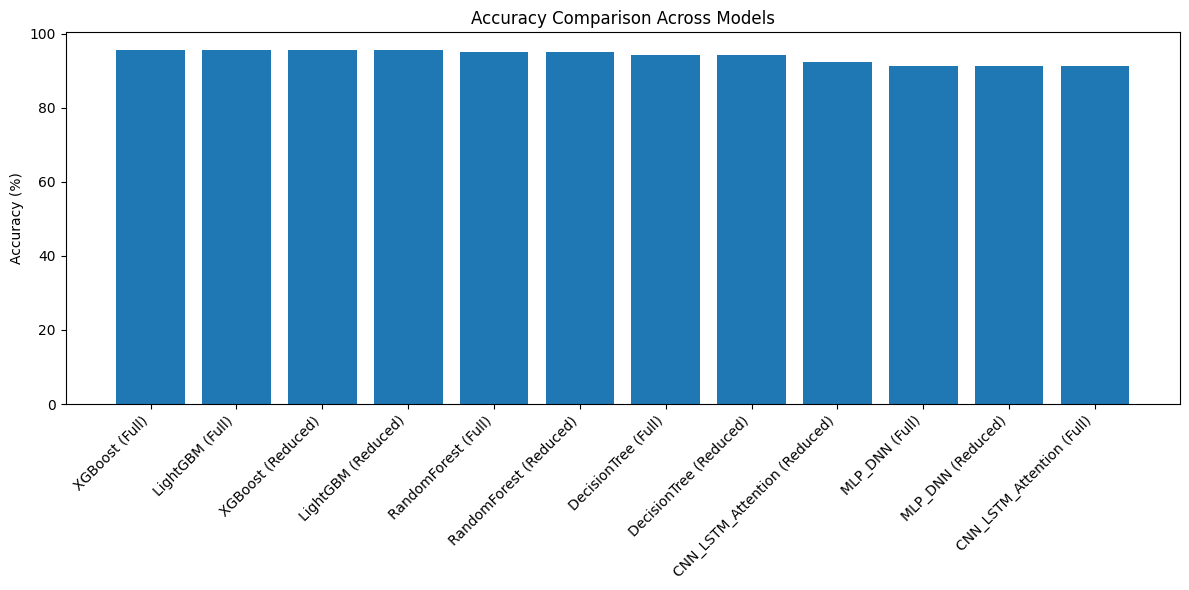

Saved: /kaggle/working/merged_idad_tabular_benchmark/paper_outputs/Fig_Accuracy_Comparison.png


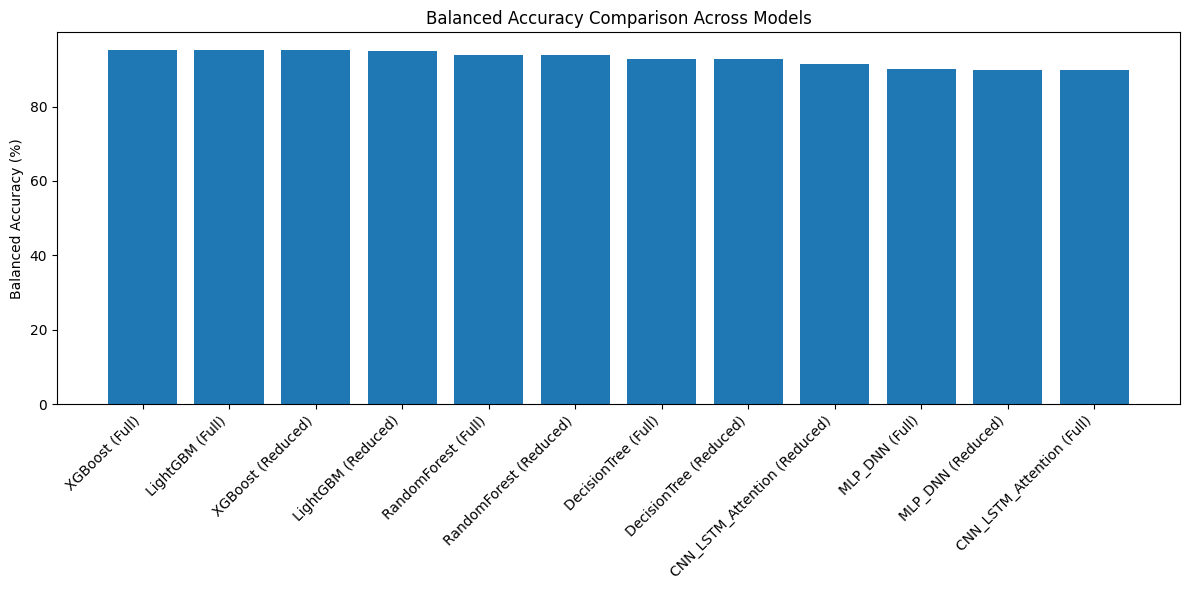

Saved: /kaggle/working/merged_idad_tabular_benchmark/paper_outputs/Fig_Balanced_Accuracy_Comparison.png


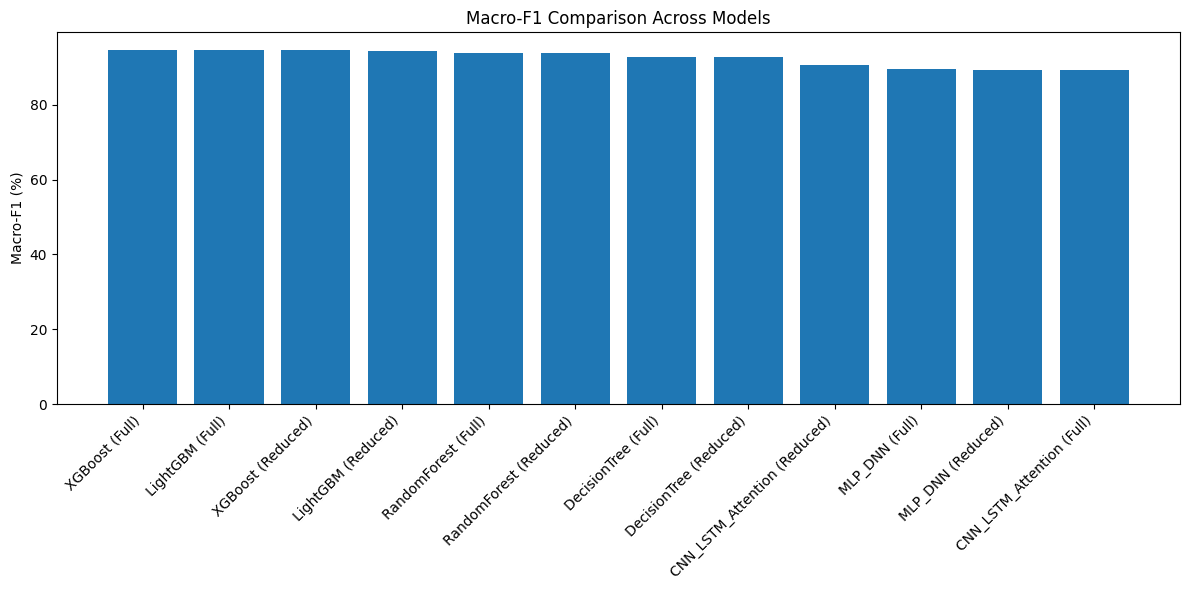

Saved: /kaggle/working/merged_idad_tabular_benchmark/paper_outputs/Fig_MacroF1_Comparison.png


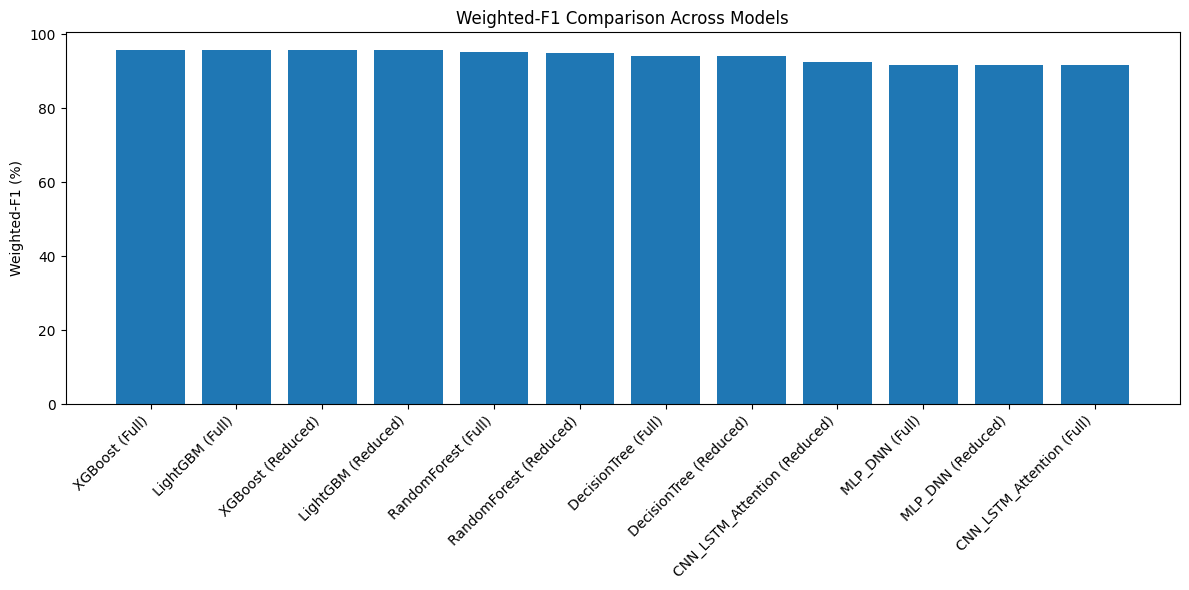

Saved: /kaggle/working/merged_idad_tabular_benchmark/paper_outputs/Fig_WeightedF1_Comparison.png


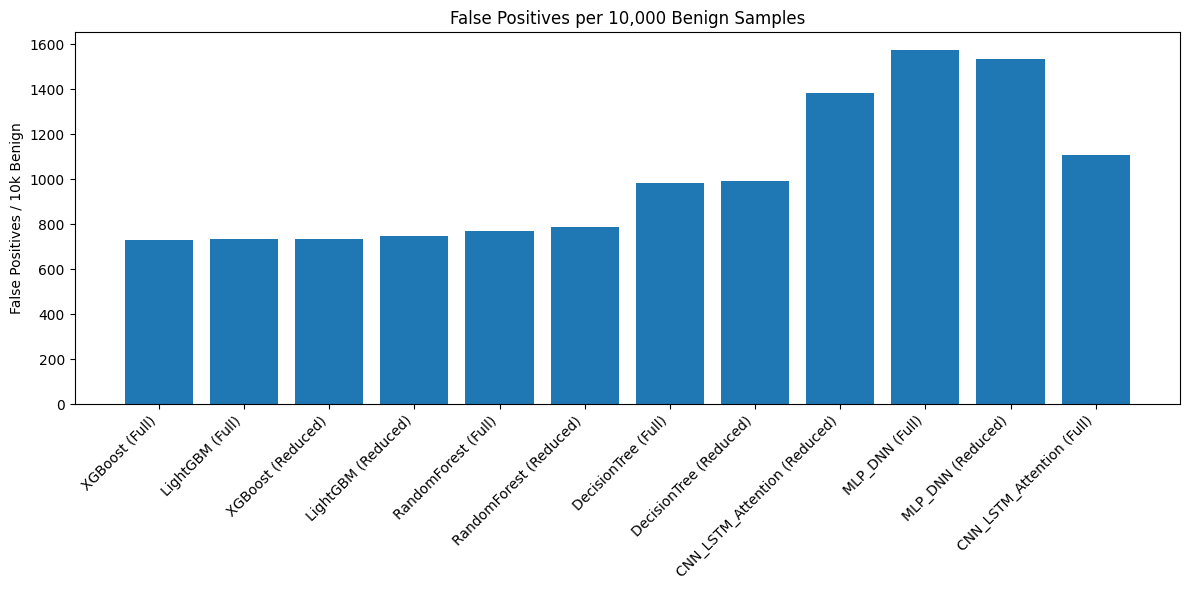

Saved: /kaggle/working/merged_idad_tabular_benchmark/paper_outputs/Fig_FP_per_10000_Benign.png


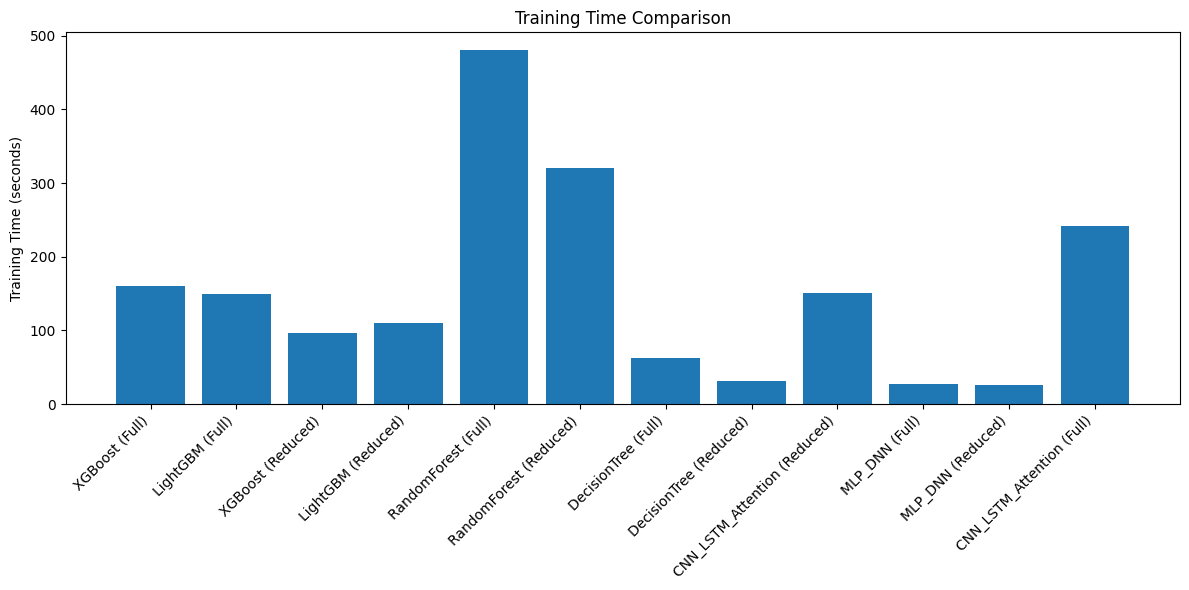

Saved: /kaggle/working/merged_idad_tabular_benchmark/paper_outputs/Fig_Training_Time.png


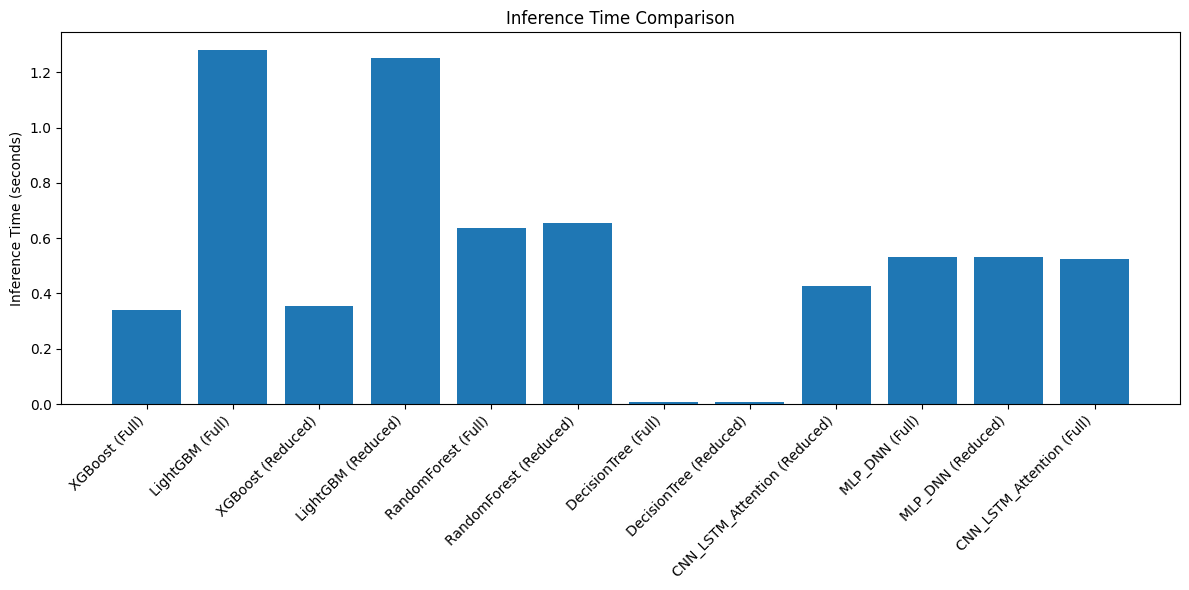

Saved: /kaggle/working/merged_idad_tabular_benchmark/paper_outputs/Fig_Inference_Time.png


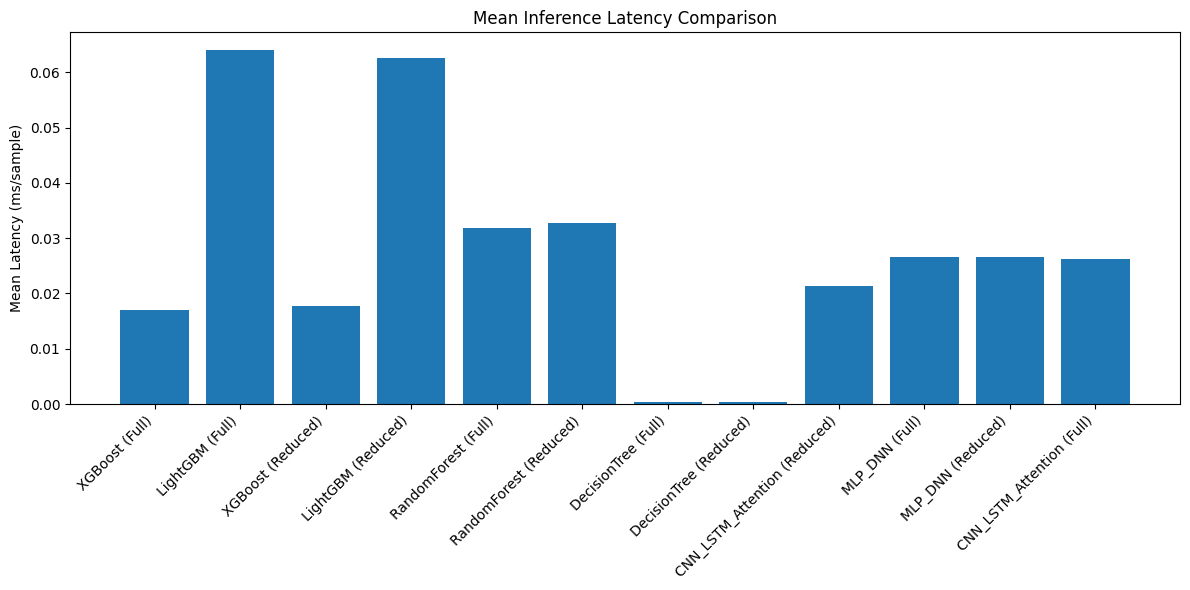

Saved: /kaggle/working/merged_idad_tabular_benchmark/paper_outputs/Fig_Mean_Latency.png


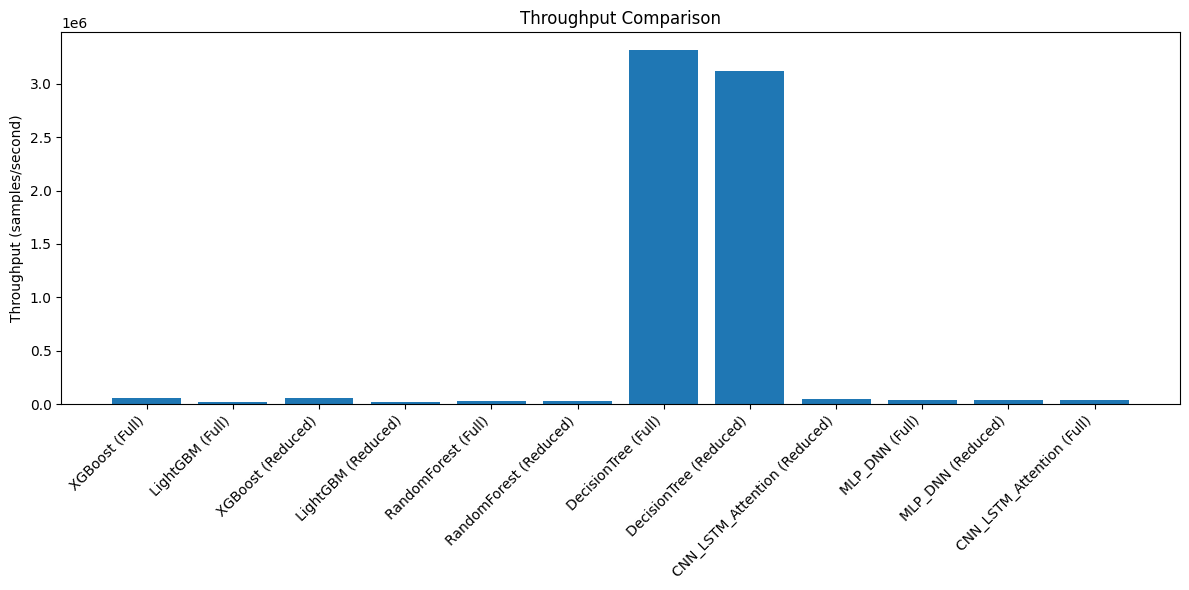

Saved: /kaggle/working/merged_idad_tabular_benchmark/paper_outputs/Fig_Throughput.png


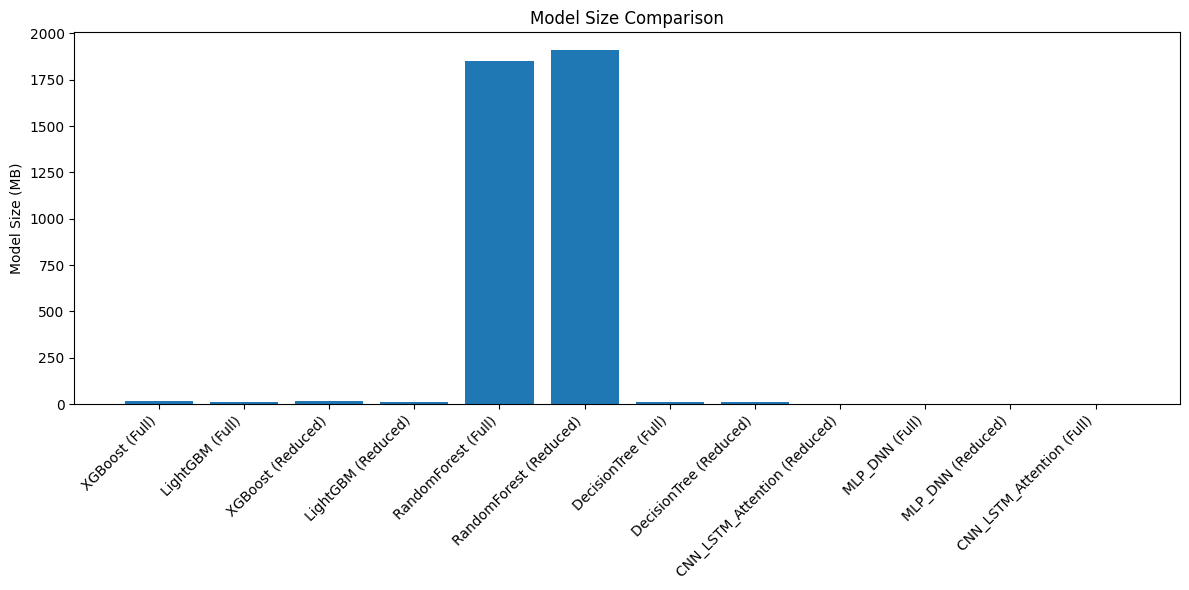

Saved: /kaggle/working/merged_idad_tabular_benchmark/paper_outputs/Fig_Model_Size.png


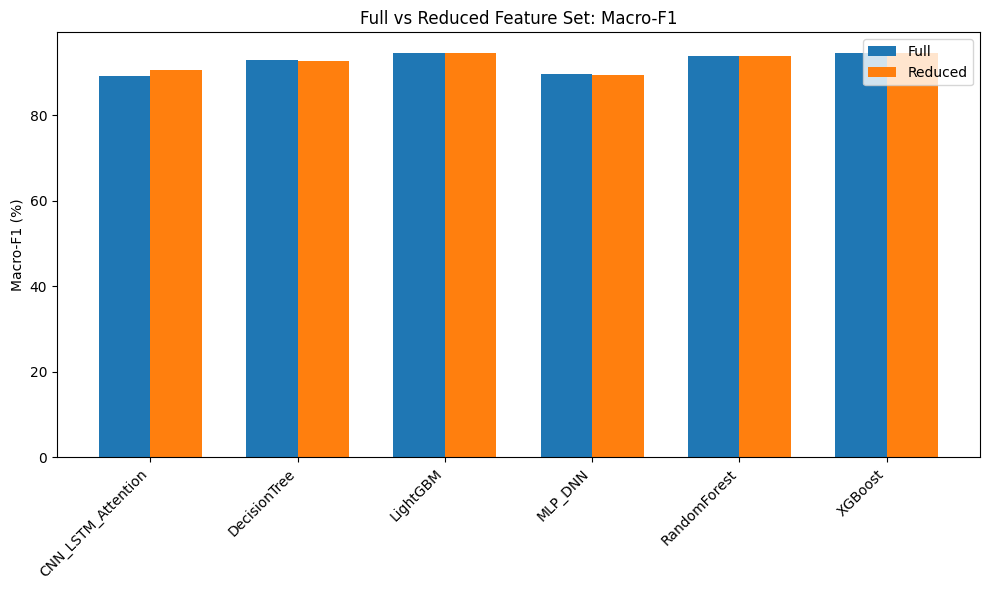

Saved: /kaggle/working/merged_idad_tabular_benchmark/paper_outputs/Fig_Full_vs_Reduced_MacroF1.png


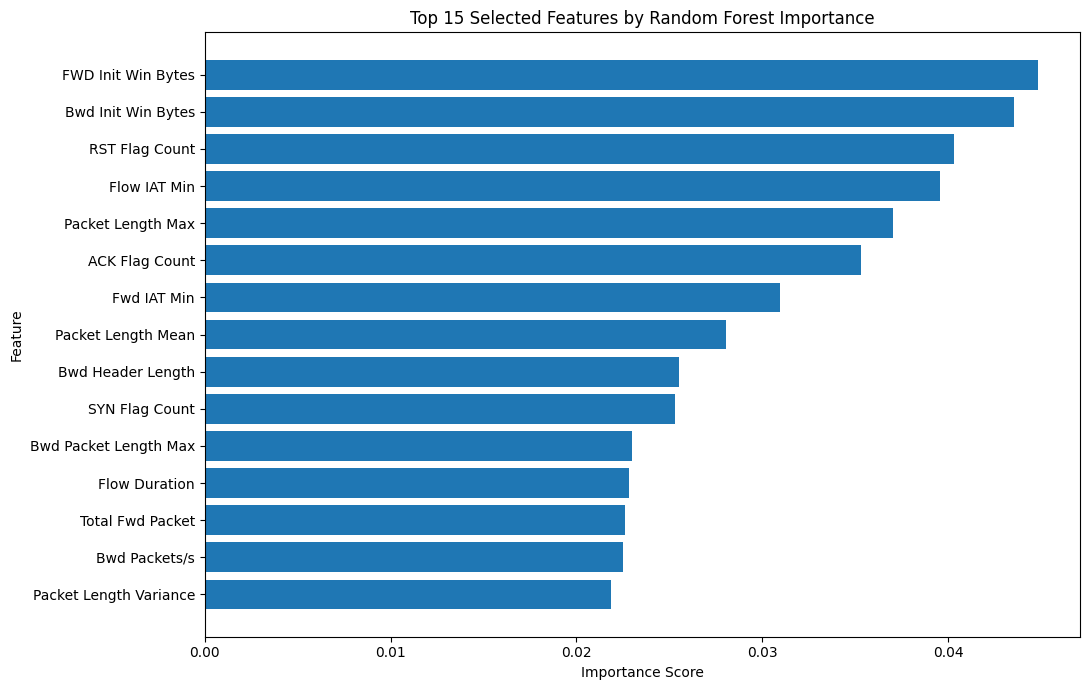

Saved: /kaggle/working/merged_idad_tabular_benchmark/paper_outputs/Fig_Top15_Feature_Importance.png
Saved confusion matrix: /kaggle/working/merged_idad_tabular_benchmark/paper_outputs/confusion_matrices/confusion_matrix_CNN_LSTM_Attention_Full.png
Saved confusion matrix: /kaggle/working/merged_idad_tabular_benchmark/paper_outputs/confusion_matrices/confusion_matrix_CNN_LSTM_Attention_Reduced.png
Saved confusion matrix: /kaggle/working/merged_idad_tabular_benchmark/paper_outputs/confusion_matrices/confusion_matrix_DecisionTree_Full.png
Saved confusion matrix: /kaggle/working/merged_idad_tabular_benchmark/paper_outputs/confusion_matrices/confusion_matrix_DecisionTree_Reduced.png
Saved confusion matrix: /kaggle/working/merged_idad_tabular_benchmark/paper_outputs/confusion_matrices/confusion_matrix_LightGBM_Full.png
Saved confusion matrix: /kaggle/working/merged_idad_tabular_benchmark/paper_outputs/confusion_matrices/confusion_matrix_LightGBM_Reduced.png
Saved confusion matrix: /kaggle/wor

/kaggle/working/paper_outputs.zip

In [15]:
# =========================
# FINAL PAPER FIGURES + ZIP CELL
# Use after Cell 26 has already created the final paper-ready table
# =========================

import os
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import FileLink, display

# ============================================================
# 1. Locate correct working folders
# ============================================================

default_final_table = Path("/kaggle/working/merged_idad_tabular_benchmark/results/final_model_comparison.csv")

if default_final_table.exists():
    final_table_path = default_final_table
else:
    matches = list(Path("/kaggle/working").rglob("final_model_comparison.csv"))
    if len(matches) == 0:
        raise FileNotFoundError(
            "final_model_comparison.csv not found.\n"
            "Run the model training/evaluation pipeline first."
        )
    final_table_path = matches[0]

WORK_DIR = final_table_path.parent.parent
RESULTS_DIR = WORK_DIR / "results"
ARTIFACTS_DIR = WORK_DIR / "artifacts"
PAPER_DIR = WORK_DIR / "paper_outputs"

PAPER_DIR.mkdir(parents=True, exist_ok=True)

print("Using folders:")
print("WORK_DIR:", WORK_DIR)
print("RESULTS_DIR:", RESULTS_DIR)
print("ARTIFACTS_DIR:", ARTIFACTS_DIR)
print("PAPER_DIR:", PAPER_DIR)
print("Final table:", final_table_path)

# ============================================================
# 2. Load final result table
# ============================================================

df = pd.read_csv(final_table_path)
print("\nLoaded final model comparison:", df.shape)
display(df.head())

# ============================================================
# 3. Plot helper
# ============================================================

def save_bar_plot(data, x_col, y_col, title, ylabel, filename, rotation=45):
    if x_col not in data.columns:
        print(f"Skipping {filename}: missing x column '{x_col}'")
        return

    if y_col not in data.columns:
        print(f"Skipping {filename}: missing y column '{y_col}'")
        return

    plot_data = data[[x_col, y_col]].dropna()

    if plot_data.empty:
        print(f"Skipping {filename}: no valid data")
        return

    plt.figure(figsize=(12, 6))
    plt.bar(plot_data[x_col].astype(str), plot_data[y_col])
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xticks(rotation=rotation, ha="right")
    plt.tight_layout()

    path = PAPER_DIR / filename
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

# ============================================================
# 4. Detection and efficiency graphs
# ============================================================

df_plot = df.copy()

if "model" in df_plot.columns and "feature_set" in df_plot.columns:
    df_plot["Model_Features"] = df_plot["model"].astype(str) + " (" + df_plot["feature_set"].astype(str) + ")"
else:
    raise KeyError("The final table must contain 'model' and 'feature_set' columns.")

if "accuracy" in df_plot.columns:
    df_plot["accuracy_pct"] = df_plot["accuracy"] * 100

if "balanced_accuracy" in df_plot.columns:
    df_plot["balanced_accuracy_pct"] = df_plot["balanced_accuracy"] * 100

if "macro_f1" in df_plot.columns:
    df_plot["macro_f1_pct"] = df_plot["macro_f1"] * 100

if "weighted_f1" in df_plot.columns:
    df_plot["weighted_f1_pct"] = df_plot["weighted_f1"] * 100

if "macro_f1_pct" in df_plot.columns:
    df_plot = df_plot.sort_values("macro_f1_pct", ascending=False)

save_bar_plot(
    df_plot,
    "Model_Features",
    "accuracy_pct",
    "Accuracy Comparison Across Models",
    "Accuracy (%)",
    "Fig_Accuracy_Comparison.png",
)

save_bar_plot(
    df_plot,
    "Model_Features",
    "balanced_accuracy_pct",
    "Balanced Accuracy Comparison Across Models",
    "Balanced Accuracy (%)",
    "Fig_Balanced_Accuracy_Comparison.png",
)

save_bar_plot(
    df_plot,
    "Model_Features",
    "macro_f1_pct",
    "Macro-F1 Comparison Across Models",
    "Macro-F1 (%)",
    "Fig_MacroF1_Comparison.png",
)

save_bar_plot(
    df_plot,
    "Model_Features",
    "weighted_f1_pct",
    "Weighted-F1 Comparison Across Models",
    "Weighted-F1 (%)",
    "Fig_WeightedF1_Comparison.png",
)

save_bar_plot(
    df_plot,
    "Model_Features",
    "fp_per_10000_benign",
    "False Positives per 10,000 Benign Samples",
    "False Positives / 10k Benign",
    "Fig_FP_per_10000_Benign.png",
)

save_bar_plot(
    df_plot,
    "Model_Features",
    "training_time_sec",
    "Training Time Comparison",
    "Training Time (seconds)",
    "Fig_Training_Time.png",
)

save_bar_plot(
    df_plot,
    "Model_Features",
    "total_inference_time_sec",
    "Inference Time Comparison",
    "Inference Time (seconds)",
    "Fig_Inference_Time.png",
)

save_bar_plot(
    df_plot,
    "Model_Features",
    "mean_latency_ms_per_sample",
    "Mean Inference Latency Comparison",
    "Mean Latency (ms/sample)",
    "Fig_Mean_Latency.png",
)

save_bar_plot(
    df_plot,
    "Model_Features",
    "throughput_samples_per_sec",
    "Throughput Comparison",
    "Throughput (samples/second)",
    "Fig_Throughput.png",
)

save_bar_plot(
    df_plot,
    "Model_Features",
    "model_size_mb",
    "Model Size Comparison",
    "Model Size (MB)",
    "Fig_Model_Size.png",
)

# ============================================================
# 5. Full vs Reduced Macro-F1 graph
# ============================================================

if {"model", "feature_set", "macro_f1"}.issubset(df.columns):
    pivot_macro = df.copy()
    pivot_macro["macro_f1_pct"] = pivot_macro["macro_f1"] * 100

    pivot_macro = pivot_macro.pivot_table(
        index="model",
        columns="feature_set",
        values="macro_f1_pct",
        aggfunc="mean",
    ).reset_index()

    if "Full" in pivot_macro.columns and "Reduced" in pivot_macro.columns:
        x = np.arange(len(pivot_macro["model"]))
        width = 0.35

        plt.figure(figsize=(10, 6))
        plt.bar(x - width / 2, pivot_macro["Full"], width, label="Full")
        plt.bar(x + width / 2, pivot_macro["Reduced"], width, label="Reduced")
        plt.title("Full vs Reduced Feature Set: Macro-F1")
        plt.ylabel("Macro-F1 (%)")
        plt.xticks(x, pivot_macro["model"], rotation=45, ha="right")
        plt.legend()
        plt.tight_layout()

        path = PAPER_DIR / "Fig_Full_vs_Reduced_MacroF1.png"
        plt.savefig(path, dpi=300, bbox_inches="tight")
        plt.show()
        print("Saved:", path)
    else:
        print("Skipping Full vs Reduced plot: Full or Reduced column missing.")
else:
    print("Skipping Full vs Reduced plot: required columns missing.")

# ============================================================
# 6. Feature importance graph
# Random Forest was used for reduced feature selection.
# Figure shows top 15 for readability.
# ============================================================

feature_importance_path = ARTIFACTS_DIR / "feature_importance_random_forest.csv"
selected_features_path = ARTIFACTS_DIR / "selected_reduced_features.csv"

if feature_importance_path.exists():
    fi = pd.read_csv(feature_importance_path)

    if {"feature", "importance"}.issubset(fi.columns):
        fi = fi.sort_values("importance", ascending=False).reset_index(drop=True)

        if selected_features_path.exists():
            selected_df = pd.read_csv(selected_features_path)
            selected_col = selected_df.columns[0]
            selected_features_list = selected_df[selected_col].astype(str).tolist()

            fi = fi[fi["feature"].astype(str).isin(selected_features_list)].copy()
            fi = fi.sort_values("importance", ascending=False).reset_index(drop=True)

            graph_title = "Top 15 Selected Features by Random Forest Importance"
        else:
            graph_title = "Top 15 Features by Random Forest Importance"

        fi_top = fi.head(15)

        if not fi_top.empty:
            plt.figure(figsize=(11, 7))
            plt.barh(fi_top["feature"].iloc[::-1], fi_top["importance"].iloc[::-1])
            plt.title(graph_title)
            plt.xlabel("Importance Score")
            plt.ylabel("Feature")
            plt.tight_layout()

            path = PAPER_DIR / "Fig_Top15_Feature_Importance.png"
            plt.savefig(path, dpi=300, bbox_inches="tight")
            plt.show()
            print("Saved:", path)
        else:
            print("Skipping feature importance graph: no matching features.")
    else:
        print("Skipping feature importance graph: required columns missing.")
else:
    print("Feature importance file not found:", feature_importance_path)

# ============================================================
# 7. Confusion matrices from saved CSV files
# ============================================================

cm_dir = PAPER_DIR / "confusion_matrices"
cm_dir.mkdir(parents=True, exist_ok=True)

cm_files = sorted(RESULTS_DIR.glob("confusion_matrix_*.csv"))

if len(cm_files) == 0:
    print("No confusion matrix CSV files found in:", RESULTS_DIR)
else:
    for cm_file in cm_files:
        try:
            cm_df = pd.read_csv(cm_file, index_col=0)
            class_names = list(cm_df.index.astype(str))
            cm = cm_df.values

            plt.figure(figsize=(7, 6))
            plt.imshow(cm)
            plt.title(cm_file.stem.replace("confusion_matrix_", "Confusion Matrix: ").replace("_", " "))
            plt.xlabel("Predicted Label")
            plt.ylabel("True Label")
            plt.xticks(np.arange(len(class_names)), class_names, rotation=45, ha="right")
            plt.yticks(np.arange(len(class_names)), class_names)

            for i in range(cm.shape[0]):
                for j in range(cm.shape[1]):
                    plt.text(j, i, str(cm[i, j]), ha="center", va="center")

            plt.colorbar()
            plt.tight_layout()

            save_path = cm_dir / f"{cm_file.stem}.png"
            plt.savefig(save_path, dpi=300, bbox_inches="tight")
            plt.close()

            print("Saved confusion matrix:", save_path)

        except Exception as e:
            print(f"Skipping confusion matrix {cm_file.name}: {e}")

# ============================================================
# 8. Zip all paper outputs
# ============================================================

zip_path = Path("/kaggle/working/paper_outputs.zip")

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(PAPER_DIR):
        for file in files:
            full_path = Path(root) / file
            arcname = full_path.relative_to(PAPER_DIR)
            zipf.write(full_path, arcname)

print("\nAll paper outputs saved to:", PAPER_DIR)
print("Zip created:", zip_path)

display(FileLink(str(zip_path)))